# Shooting Method — A Simple Introduction

The **shooting method** can be used for solving a two-point boundary value problem (BVP)
$ y'' = f(x, y, y'), \quad y(a)=\alpha,\; y(b)=\beta.$

Idea: convert the BVP to a family of **initial value problems (IVPs)** parameterized by an unknown initial slope \(s = y'(a)\). For each trial \(s\), we solve the IVP from $x=a$ to $x=b$ and look at the mismatch at the right boundary, 
$\varphi(s) = y_s(b) - \beta$. We then **root-find** on $\varphi(s)=0$ to discover the correct $s$.

We'll use a very simple example with a known exact solution so we can verify accuracy:

**Problem:**  Solve $y'' + y = 0$ on $[0, \pi/2]$ with $y(0)=0$ and $y(\pi/2)=1$.

- Exact solution: $y(x) = \sin x$.
- Therefore the true initial slope is $y'(0)=1$.

![shooting_method_corrected.png](shooting_method_corrected.png)

## Step 1 — Convert to first-order system
Let $y_0 = y$ and $y_1 = y'$. Then
$ y_1' = y_2, \quad y_2' = -y_1. $

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def rhs(x, Y):
    """Right-hand side for y'' + y = 0 in first-order form.
    Y = [y0, y1] with y1' = y2, y1' = -y0.
    """
    y0, y1 = Y
    return np.array([y1, -y0], dtype=float)

## Step 2 — An IVP solver (RK4, fixed step)
We implement a simple 4th-order Runge–Kutta (RK4) to evolve from \(a\) to \(b\) given initial values \(y(a)=\alpha\) and \(y'(a)=s\).

In [7]:
def rk4(rhs, a, b, Y0, N=1000):
    """Fixed-step RK4 integrator for a system Y' = rhs(x, Y).
    Returns x-grid and solution array of shape (N+1, len(Y0)).
    """
    x = np.linspace(a, b, N+1)
    h = (b - a)/N
    Y = np.zeros((N+1, len(Y0)))
    Y[0] = np.array(Y0, dtype=float)
    for k in range(N):
        Xk = x[k]
        Yk = Y[k]
        k1 = rhs(Xk, Yk)
        k2 = rhs(Xk + 0.5*h, Yk + 0.5*h*k1)
        k3 = rhs(Xk + 0.5*h, Yk + 0.5*h*k2)
        k4 = rhs(Xk + h,     Yk + h*k3)
        Y[k+1] = Yk + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return x, Y

## Step 3 — Define the shooting residual $\varphi(s)$
For a trial slope \(s\), integrate the IVP and return the boundary mismatch $\varphi(s) = y(b) - \beta$.

In [8]:
a, b = 0.0, 0.5*np.pi     # interval [0, pi/2]
alpha, beta = 0.0, 1.0    # y(a)=alpha, y(b)=beta

def phi(s, N=1000):
    # Initial state uses y(a)=alpha and y'(a)=s
    x, Y = rk4(rhs, a, b, Y0=[alpha, s], N=N)
    y_end = Y[-1, 0]  # y(b)
    return y_end - beta

## Step 4 — Find the correct slope via the secant method
We solve $\varphi(s)=0$ with a simple secant iteration using two starting guesses that bracket the true value in this example (0 and 2). For this particular linear problem, $\varphi$ is monotone, so this works very reliably.

In [9]:
def secant(g, s0, s1, tol=1e-10, maxiter=50):
    f0 = g(s0)
    f1 = g(s1)
    for k in range(maxiter):
        if abs(f1 - f0) < 1e-30:
            break
        s2 = s1 - f1*(s1 - s0)/(f1 - f0)
        if abs(s2 - s1) <= tol*(1 + abs(s2)):
            return s2
        s0, f0, s1, f1 = s1, f1, s2, g(s2)
    return s1  # best available

In [10]:
# Solve for the initial slope
s_star = secant(phi, 0.0, 2.0, tol=1e-12)
s_star

np.float64(1.0)

## Step 5 — Integrate with the found slope and compare to the exact solution
The exact solution is $y(x)=\sin x$. We plot the numerical shooting solution and compute a max-norm error.

In [11]:
x, Y = rk4(rhs, a, b, Y0=[alpha, s_star], N=1000)
y_num = Y[:,0]
y_exact = np.sin(x)
max_err = np.max(np.abs(y_num - y_exact))
float(max_err)

2.8976820942716586e-14

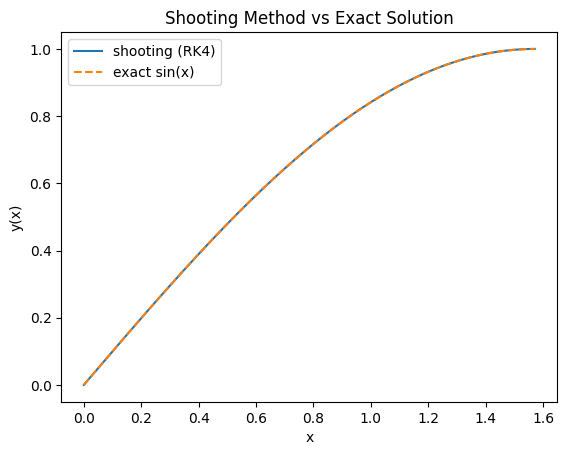

In [12]:
plt.figure()
plt.plot(x, y_num, label="shooting (RK4)")
plt.plot(x, y_exact, linestyle='--', label="exact sin(x)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Shooting Method vs Exact Solution")
plt.legend()
plt.show()

## Using SciPy
With `scipy` installed, the shooting method becomes very compact using `solve_ivp` and `root_scalar`.

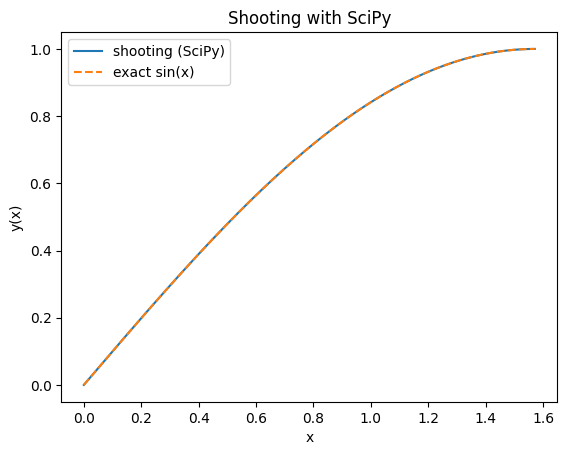

s* (SciPy) = 1.0000000001888005


In [13]:
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

def phi_scipy(s):
    sol = solve_ivp(lambda x, Y: rhs(x, Y), (a, b), [alpha, s], rtol=1e-9, atol=1e-12)
    yb = sol.y[0, -1]
    return yb - beta

r = root_scalar(phi_scipy, bracket=[0.0, 2.0], method='brentq', xtol=1e-12)
s_star_scipy = r.root
x2 = np.linspace(a, b, 1001)
sol2 = solve_ivp(lambda x, Y: rhs(x, Y), (a, b), [alpha, s_star_scipy], t_eval=x2, rtol=1e-9, atol=1e-12)
y2 = sol2.y[0]
plt.figure()
plt.plot(x2, y2, label="shooting (SciPy)")
plt.plot(x2, np.sin(x2), linestyle='--', label="exact sin(x)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Shooting with SciPy")
plt.legend()
plt.show()
print("s* (SciPy) =", s_star_scipy)


## Try it yourself
- Change the right boundary value `beta` and re-run.
- Replace the ODE with a nonlinear one (e.g., `y2' = -y1 + y1**3`).
- Compare secant with a bracketing method (bisection) for robustness.
- Explore *multiple shooting*: split the interval and match at interior points (useful for stiff or chaotic systems).

#### Exercises

**1)**  Linear test case: $y''=-\pi^2 y$, $y(0)=0$, $y(1)=0$    
Plot $y(x)$.

#### How to avoid the trivial solution $y(x)=0$.

The brief conclusion: shoot with  a parameter standing in for $\pi^2$ rather than the actual slope at the   
beginning of your domain. The diffeq is linear and homgeneous so if $f(x)$ is a solution,    $Af(x)$ is also a solution. Changing the slope at $x=0$ is equivalent to changing the value of $A$. So, if $f(x)$   
doesn't satisfy the boundary conditions, then changing the slope won't help. It will just change the    scale or size of your solution. If your residual is different from zero, changing the slope won't change    the fundamental **shape** of your solution so you won't get it to bend toward your BC at the far   end of your domain. But shooting (varying) the parameter multiplying $y(x)$ instead of the slope $y'(x)$ is the way to proceed. This siuation is common so it is good to know how to deal with it. Here is the self-contained code: 

In [ ]:
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
import numpy as np
import matplotlib.pyplot as plt



def ode(x, Y, lam):
    y, yp = Y
    return [yp, -lam * y]   # -lam is a stand in for pi^2


def residual(lam):
    # y(0)=0, y'(0)=1 (fix amplitude scale)
    sol = solve_ivp(lambda x, Y: ode(x, Y, lam), [0, 1], [0.0, 1.0], t_eval=[1.0])
    return sol.y[0, -1]   # want y(1)=0. What is returned is the residual: sol[y,-1] - 0.

#Find the value of lam that puts residual close to zero.
lam_sol = root_scalar(residual, bracket=[0.0, 20.0], method='brentq', xtol=1e-12)
r = lam_sol.root   # actual root, lam_sol has much info
print("Our root to many sig figs:",r)     # should be close to pi^2 according to our diffeq.

# Integrate with that r to get the shape.
xs = np.linspace(0, 1, 400)
sol = solve_ivp(lambda x, Y: ode(x, Y, r), [0, 1], [0.0, 1.0], t_eval=xs)
ys = sol.y[0]
print("The parameter lam =",round(r,4))


plt.figure()
plt.plot(xs,ys)
# can add labels and title in standard way.
plt.grid(True)
plt.show()

#### 2) Schrödinger in an infinite square well (units $\hbar^2/2m=1$)
On $x \in [0,L]$ with $V=0$, we solve $\psi'' + E\psi=0$ and **shoot on $E$** so that $\psi(L)=0$.

Find the two lowest energies for this potential and plot $\psi(x)$. You can choose $L=1$.

**3)** Projectile to a fixed range (no drag).   
With $x$ as the independent variable:
$$
 y''(x) = -\frac{g}{v_0^2}\,\big(1 + (y')^2\big)^{3/2}, \quad y(0)=0,\; y(x_f)=0.
 $$
 
The **unknown initial slope** $s=y'(0)=\tan\theta_0$ is adjusted so that the projectile returns to $y=0$ at $x_f$.    
Use (ignoring units since all are in the SI system of units):   
$g = 9.81$    
$v_0 = 30.0$    
$x_f = 60.0$    
Plot $y(x)$

**4)** Heat conduction in a rod: $T''=-Q/k$, $T(0)=T_0$, $T(L)=T_L$   
$L = 1.0$    
$T_0, T_L = 300.0, 350.0$    
$\frac{Q}{k}= 50.0$    
All quantities in SI units.    
Plot $T(x)$.

<style>
.red  { color: #d00; }
.blue { color: #1e90ff; }
.note { border-left: 6px solid #1e90ff; background:#f1f8ff; padding:.6em 1em; border-radius:.25rem; }
.warn { border-left: 6px solid #d9534f; background:#fff5f5; padding:.6em 1em; border-radius:.25rem; }
</style>